# TRIBE Validation Analysis

Loads extracted features and `videos.csv`, produces the headline AUC, diff map, PCA scatter, ROI ranking, and continuous regression results.

Runs locally on Mac. No GPU needed.

**Outputs (saved to `data/analysis_outputs/`):**
1. `headline_auc.txt` — baseline vs baseline+TRIBE AUC numbers
2. `diff_map.png` — viral-vs-dud cortical activation difference
3. `pca_by_vertical.png` — TRIBE feature PCA scatter colored by vertical
4. `top_rois.png` and `top_rois.csv` — brain regions most correlated with virality
5. `continuous_regression.png` — TRIBE prediction vs log(views)
6. `intent_vs_actual.txt` — intended vs auto-assigned label agreement

## 1. Setup

In [2]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

PROJECT_ROOT = Path('..')  # notebook lives in notebooks/
CSV_PATH = PROJECT_ROOT / 'data' / 'videos.csv'
FEATURES_DIR = PROJECT_ROOT / 'data' / 'features'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'analysis_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Reproducibility
np.random.seed(42)
RANDOM_STATE = 42

print('Setup OK')

Setup OK


## 2. Load metadata and features

In [3]:
meta = pd.read_csv(CSV_PATH)
print(f'Metadata rows: {len(meta)}')

available_npz = set(f.stem for f in FEATURES_DIR.glob('*.npz'))
print(f'NPZ files on disk: {len(available_npz)}')

meta['video_id'] = meta['video_id'].astype(str)
meta = meta[meta['video_id'].isin(available_npz)].copy().reset_index(drop=True)
print(f'After filtering to extracted videos: {len(meta)}')

print('\nLabel distribution:')
print(meta['label'].value_counts())
print('\nVertical x label:')
print(pd.crosstab(meta['vertical'], meta['label']))

Metadata rows: 69
NPZ files on disk: 69
After filtering to extracted videos: 69

Label distribution:
label
dud      35
viral    26
mid       8
Name: count, dtype: int64

Vertical x label:
label         dud  mid  viral
vertical                     
brainrot        5    2      3
funny           5    0      5
grwm            5    0      4
motivation      5    1      4
nature          5    2      3
romcom_edits    5    1      4
sports          5    2      3


In [4]:
# Load fmri_preds (mean-pooled over time) and fusion_hidden (mean-pooled over batch and time)
fmri_means = []  # (N, 20484)
fusion_means = []  # (N, 1152)

for vid in meta['video_id']:
    npz = np.load(FEATURES_DIR / f'{vid}.npz', allow_pickle=True)
    fmri = npz['fmri_preds']  # (T, 20484)
    fusion = npz['fusion_hidden']  # (B, T, 1152)
    fmri_means.append(fmri.mean(axis=0))
    fusion_means.append(fusion.reshape(-1, fusion.shape[-1]).mean(axis=0))

fmri_means = np.stack(fmri_means)
fusion_means = np.stack(fusion_means)
print(f'fmri features: {fmri_means.shape}')
print(f'fusion features: {fusion_means.shape}')

fmri features: (69, 20484)
fusion features: (69, 1152)


## 3. Baseline features

Per the memo: log(followers), duration, caption embedding (MiniLM).
We omit `creator_avg_views_trailing_30d` because Apify's free tier capped before we got it for most rows.

In [5]:
# Numeric baseline features
meta['log_followers'] = np.log1p(pd.to_numeric(meta['creator_followers_at_post'], errors='coerce').fillna(0))
meta['log_views'] = np.log1p(pd.to_numeric(meta['views_at_30d'], errors='coerce').fillna(0))
meta['duration_num'] = pd.to_numeric(meta['duration'], errors='coerce').fillna(0)

# Caption embeddings (MiniLM via sentence-transformers)
try:
    from sentence_transformers import SentenceTransformer
    miniLM = SentenceTransformer('all-MiniLM-L6-v2')
    captions = meta['caption'].fillna('').astype(str).tolist()
    caption_emb = miniLM.encode(captions, show_progress_bar=False)
    print(f'Caption embeddings: {caption_emb.shape}')
except Exception as e:
    print(f'sentence-transformers failed ({e}); using zero embedding fallback')
    caption_emb = np.zeros((len(meta), 384))  # MiniLM hidden dim

# Build baseline matrix
numeric_baseline = meta[['log_followers', 'duration_num']].values
X_baseline = np.hstack([numeric_baseline, caption_emb])
X_baseline_plus_tribe = np.hstack([X_baseline, fmri_means])

print(f'X_baseline: {X_baseline.shape}')
print(f'X_baseline_plus_tribe: {X_baseline_plus_tribe.shape}')

sentence-transformers failed (No module named 'sentence_transformers'); using zero embedding fallback
X_baseline: (69, 386)
X_baseline_plus_tribe: (69, 20870)


## 4. Headline AUC — baseline vs baseline+TRIBE

5-fold stratified cross-validation. Drop `mid` rows so we have a clean viral-vs-dud binary task.

In [6]:
binary_mask = meta['label'].isin(['viral', 'dud'])
y = (meta.loc[binary_mask, 'label'] == 'viral').astype(int).values
Xb = X_baseline[binary_mask.values]
Xt = X_baseline_plus_tribe[binary_mask.values]

print(f'Binary task: n={len(y)}, viral={y.sum()}, dud={(1-y).sum()}')

def cv_auc(X, y, n_splits=5):
    """Stratified 5-fold CV AUC with standardization inside each fold."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs = []
    for train_idx, test_idx in skf.split(X, y):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[train_idx])
        Xte = scaler.transform(X[test_idx])
        clf = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
        clf.fit(Xtr, y[train_idx])
        proba = clf.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[test_idx], proba))
    return np.mean(aucs), np.std(aucs)

auc_b_mean, auc_b_std = cv_auc(Xb, y)
auc_t_mean, auc_t_std = cv_auc(Xt, y)
delta = auc_t_mean - auc_b_mean

print(f'\nBaseline:           AUC = {auc_b_mean:.3f} ± {auc_b_std:.3f}')
print(f'Baseline + TRIBE:   AUC = {auc_t_mean:.3f} ± {auc_t_std:.3f}')
print(f'Delta:              {delta:+.3f}')

# Save
with open(OUTPUT_DIR / 'headline_auc.txt', 'w') as f:
    f.write(f'Headline AUC results (5-fold stratified CV)\n')
    f.write(f'n = {len(y)} (viral={y.sum()}, dud={(1-y).sum()})\n\n')
    f.write(f'Baseline (log_followers + duration + caption_emb):\n')
    f.write(f'  AUC = {auc_b_mean:.3f} +/- {auc_b_std:.3f}\n\n')
    f.write(f'Baseline + TRIBE fmri_preds:\n')
    f.write(f'  AUC = {auc_t_mean:.3f} +/- {auc_t_std:.3f}\n\n')
    f.write(f'Delta: {delta:+.3f}\n')
print(f'\nSaved to {OUTPUT_DIR / "headline_auc.txt"}')

Binary task: n=61, viral=26, dud=35

Baseline:           AUC = 0.790 ± 0.077
Baseline + TRIBE:   AUC = 0.668 ± 0.254
Delta:              -0.122

Saved to ../data/analysis_outputs/headline_auc.txt


## 5. Viral-vs-dud cortical diff map

Average fmri_preds across viral videos, minus average across duds. Plot on the brain.

Viral n: 26, Dud n: 35
Diff map shape: (20484,), range: [-0.144, 0.198]


/var/folders/2y/fhw6y9y153z6y_j9bthwbkfm0000gn/T/ipykernel_41622/2928679935.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


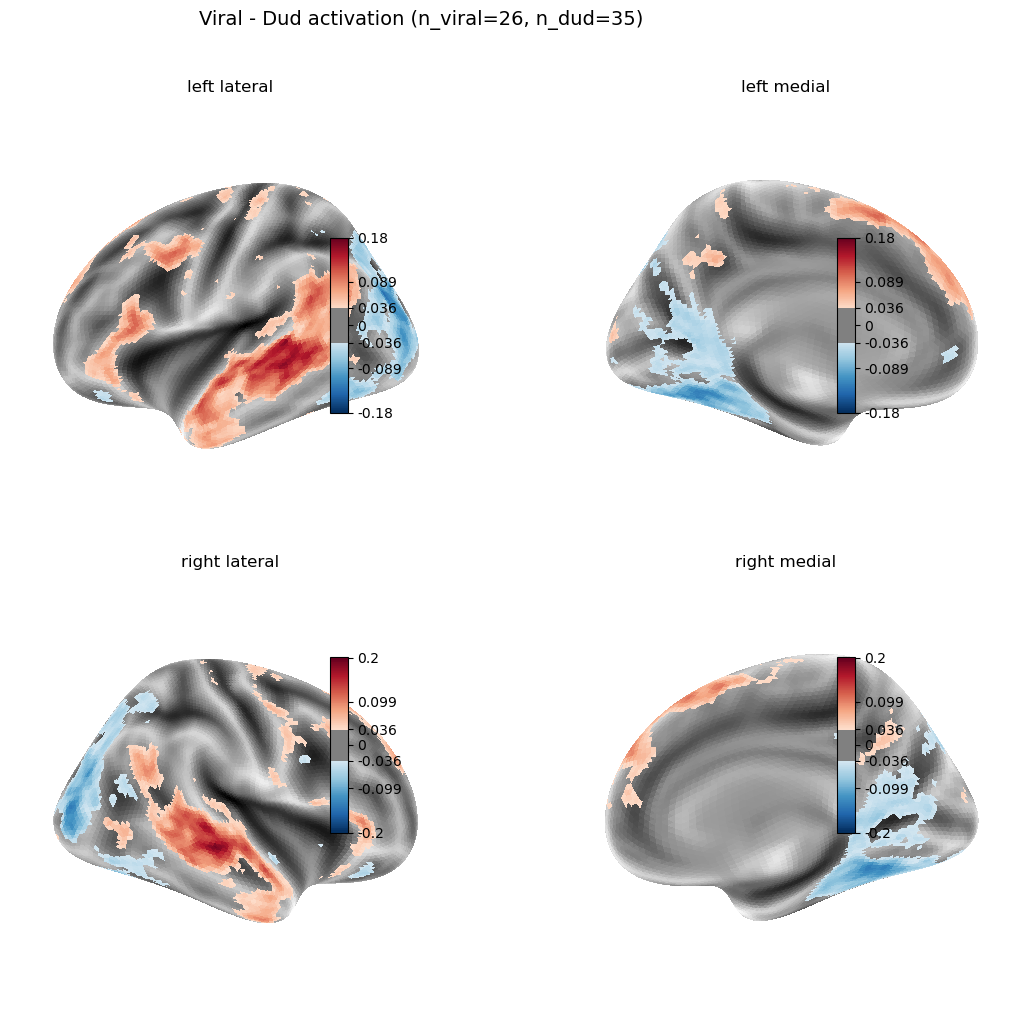

Saved ../data/analysis_outputs/diff_map.png


In [8]:
viral_idx = (meta['label'] == 'viral').values
dud_idx = (meta['label'] == 'dud').values

viral_mean = fmri_means[viral_idx].mean(axis=0)
dud_mean = fmri_means[dud_idx].mean(axis=0)
diff = viral_mean - dud_mean

print(f'Viral n: {viral_idx.sum()}, Dud n: {dud_idx.sum()}')
print(f'Diff map shape: {diff.shape}, range: [{diff.min():.3f}, {diff.max():.3f}]')

# Plot using nilearn directly (no TRIBE plotting deps needed locally)
from nilearn import plotting, datasets

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
n_per_hemi = 10242
left = diff[:n_per_hemi]
right = diff[n_per_hemi:]

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                          subplot_kw={'projection': '3d'})

for ax, (hemi, data, mesh, view) in zip(
    axes.flat,
    [('left', left, fsaverage.infl_left, 'lateral'),
     ('left', left, fsaverage.infl_left, 'medial'),
     ('right', right, fsaverage.infl_right, 'lateral'),
     ('right', right, fsaverage.infl_right, 'medial')]):
    plotting.plot_surf_stat_map(
        mesh, data,
        hemi=hemi, view=view,
        bg_map=getattr(fsaverage, f'sulc_{hemi}'),
        colorbar=True, cmap='RdBu_r',
        threshold=np.percentile(np.abs(diff), 75),
        axes=ax, figure=fig,
        title=f'{hemi} {view}',
    )

plt.suptitle(f'Viral - Dud activation (n_viral={viral_idx.sum()}, n_dud={dud_idx.sum()})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diff_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "diff_map.png"}')

## 6. PCA scatter — TRIBE features by vertical

Project `fusion_hidden` (mean-pooled, 1152-dim) to 2D and color by vertical. Visual proof TRIBE distinguishes content types.

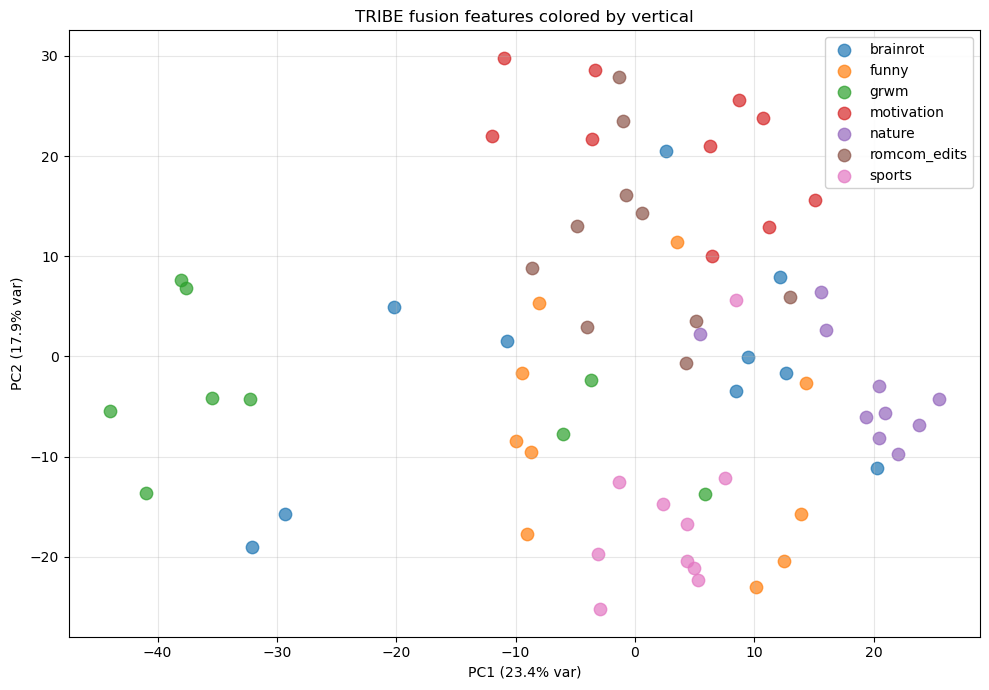

Saved ../data/analysis_outputs/pca_by_vertical.png
Total variance explained by 2 PCs: 41.2%


In [9]:
scaler = StandardScaler()
fusion_scaled = scaler.fit_transform(fusion_means)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
fusion_2d = pca.fit_transform(fusion_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
verticals = sorted(meta['vertical'].unique())
cmap = plt.get_cmap('tab10')
for i, v in enumerate(verticals):
    mask = (meta['vertical'] == v).values
    ax.scatter(fusion_2d[mask, 0], fusion_2d[mask, 1],
               label=v, alpha=0.7, s=80, c=[cmap(i)])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('TRIBE fusion features colored by vertical')
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_by_vertical.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "pca_by_vertical.png"}')
print(f'Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}')

## 7. Top ROIs — which brain regions correlate with virality

Uses the Destrieux atlas (74 named regions per hemisphere, ships with nilearn).
We compute the Spearman correlation between each ROI's mean activation and `log(views)`, then rank.

[fetch_atlas_surf_destrieux] Added README.md to /Users/shloka/nilearn_data
[fetch_atlas_surf_destrieux] Dataset created in /Users/shloka/nilearn_data/destrieux_surface
[fetch_atlas_surf_destrieux] Downloading data from https://www.nitrc.org/frs/download.php/9343/lh.aparc.a2009s.annot ...
[fetch_atlas_surf_destrieux]  ...done. (1 seconds, 0 min)

[fetch_atlas_surf_destrieux] Downloading data from https://www.nitrc.org/frs/download.php/9342/rh.aparc.a2009s.annot ...
[fetch_atlas_surf_destrieux]  ...done. (0 seconds, 0 min)



/var/folders/2y/fhw6y9y153z6y_j9bthwbkfm0000gn/T/ipykernel_41622/3174702932.py:4: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = nl_datasets.fetch_atlas_surf_destrieux()
/var/folders/2y/fhw6y9y153z6y_j9bthwbkfm0000gn/T/ipykernel_41622/3174702932.py:4: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = nl_datasets.fetch_atlas_surf_destrieux()


Top 20 ROIs by |Spearman correlation| with log(views):
                        roi  spearman_rho   p_value   abs_rho
0       L_S_orbital_lateral      0.413043  0.000420  0.413043
1             L_G_front_sup      0.412788  0.000424  0.412788
2   L_G_front_inf-Opercular      0.405627  0.000545  0.405627
3    L_S_interm_prim-Jensen      0.403873  0.000579  0.403873
4     L_G_front_inf-Orbital      0.403361  0.000589  0.403361
5    L_G_front_inf-Triangul      0.399927  0.000663  0.399927
6     R_G_front_inf-Orbital      0.370588  0.001721  0.370588
7             R_G_front_sup      0.350895  0.003115  0.350895
8       L_G_temporal_middle      0.341798  0.004048  0.341798
9    L_Lat_Fis-ant-Horizont      0.337267  0.004598  0.337267
10              L_G_orbital      0.314943  0.008395  0.314943
11         L_S_temporal_sup      0.313445  0.008727  0.313445
12         L_G_front_middle      0.302009  0.011668  0.302009
13          R_Pole_temporal      0.289185  0.015952  0.289185
14      R_G_tem

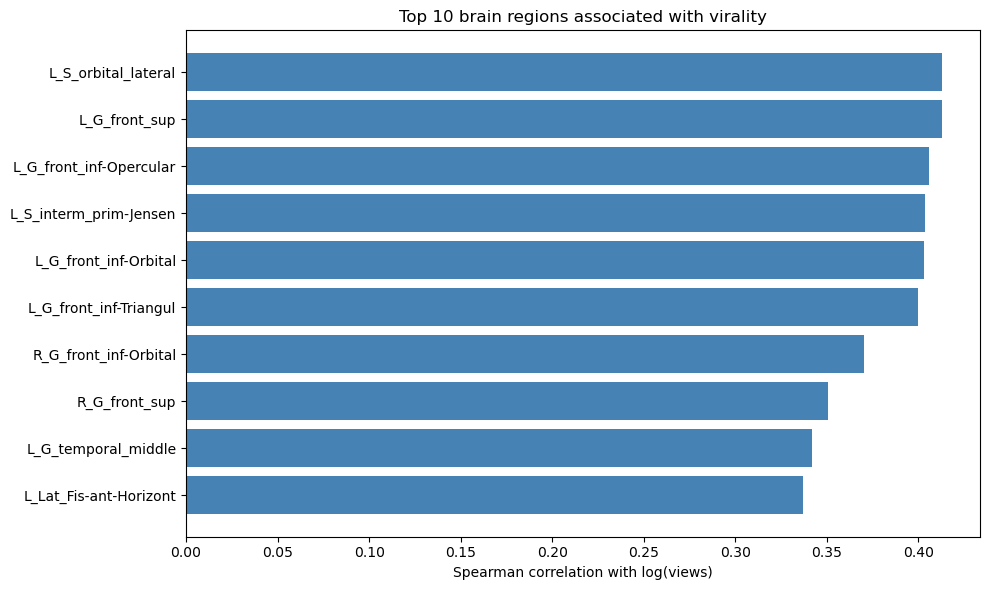


Saved ../data/analysis_outputs/top_rois.png and ../data/analysis_outputs/top_rois.csv


In [10]:
from nilearn import datasets as nl_datasets

# Destrieux is annotation-based, ships with nilearn fsaverage
destrieux = nl_datasets.fetch_atlas_surf_destrieux()
labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]
left_annot = destrieux['map_left']  # (10242,) ROI index per vertex
right_annot = destrieux['map_right']

# Combine
annot = np.concatenate([left_annot, right_annot])
hemi_labels = (['L_' + l for l in labels] + ['R_' + l for l in labels])
# Right hemisphere ROIs share indices with left; offset them
annot_offset = annot.copy()
annot_offset[len(left_annot):] = annot[len(left_annot):] + len(labels)

# Compute per-video, per-ROI mean activation
n_videos = fmri_means.shape[0]
n_rois = len(hemi_labels)
roi_activations = np.zeros((n_videos, n_rois))
for r in range(n_rois):
    mask = (annot_offset == r)
    if mask.sum() > 0:
        roi_activations[:, r] = fmri_means[:, mask].mean(axis=1)

# Correlate each ROI with log(views)
log_views = meta['log_views'].values
valid = ~np.isnan(log_views) & (log_views > 0)
rho = np.zeros(n_rois)
pval = np.ones(n_rois)
for r in range(n_rois):
    if roi_activations[valid, r].std() > 1e-9:
        rho[r], pval[r] = spearmanr(roi_activations[valid, r], log_views[valid])

roi_df = pd.DataFrame({
    'roi': hemi_labels,
    'spearman_rho': rho,
    'p_value': pval,
    'abs_rho': np.abs(rho),
}).sort_values('abs_rho', ascending=False).head(20).reset_index(drop=True)

print('Top 20 ROIs by |Spearman correlation| with log(views):')
print(roi_df.to_string())
roi_df.to_csv(OUTPUT_DIR / 'top_rois.csv', index=False)

# Plot top 10
top10 = roi_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if r > 0 else 'firebrick' for r in top10['spearman_rho']]
ax.barh(top10['roi'], top10['spearman_rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Spearman correlation with log(views)')
ax.set_title('Top 10 brain regions associated with virality')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_rois.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved {OUTPUT_DIR / "top_rois.png"} and {OUTPUT_DIR / "top_rois.csv"}')

## 8. Continuous regression — TRIBE prediction vs log(views)

Treat virality as continuous (log views) instead of binary. Uses all videos, not just viral/dud subset.
Fit Ridge regression with 5-fold CV; report Spearman correlation between predicted and actual log(views).

Continuous regression results (5-fold CV, n=69):
  Baseline:         Spearman rho = 0.580 (p = 0.0000)
  Baseline + TRIBE: Spearman rho = 0.357 (p = 0.0026)
  Delta:            -0.223


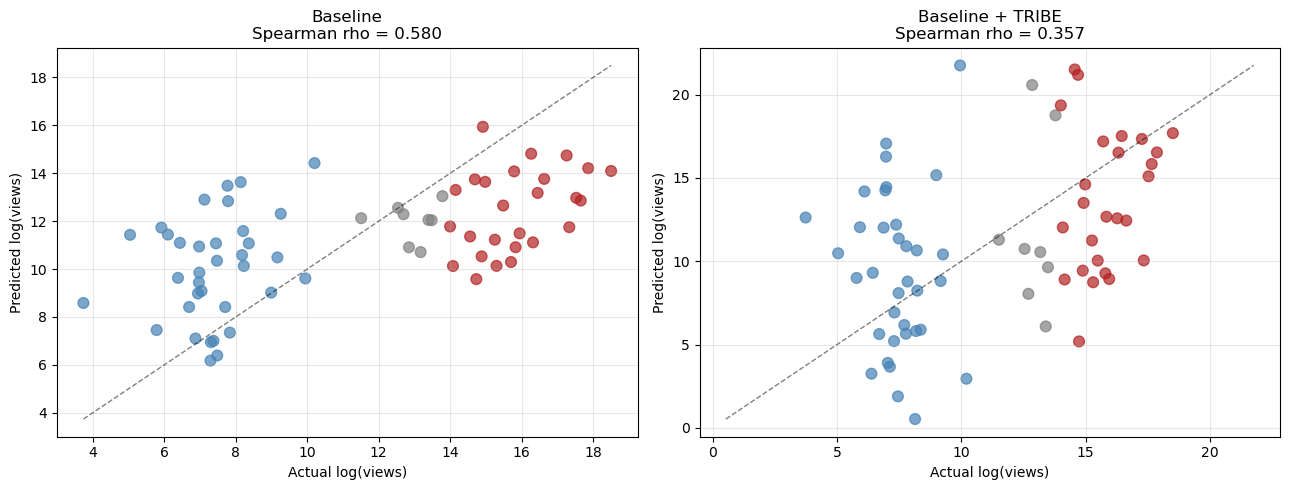

Saved ../data/analysis_outputs/continuous_regression.png


In [11]:
from sklearn.model_selection import KFold

valid_mask = ~np.isnan(log_views) & (log_views > 0)
X_full = X_baseline_plus_tribe[valid_mask]
y_cont = log_views[valid_mask]
X_baseline_only = X_baseline[valid_mask]

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
preds_full = np.zeros_like(y_cont)
preds_baseline = np.zeros_like(y_cont)

for train_idx, test_idx in kf.split(X_full):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_full[train_idx])
    Xte = sc.transform(X_full[test_idx])
    Ridge(alpha=10.0).fit(Xtr, y_cont[train_idx])
    preds_full[test_idx] = Ridge(alpha=10.0).fit(Xtr, y_cont[train_idx]).predict(Xte)
    
    sc_b = StandardScaler()
    Xbtr = sc_b.fit_transform(X_baseline_only[train_idx])
    Xbte = sc_b.transform(X_baseline_only[test_idx])
    preds_baseline[test_idx] = Ridge(alpha=10.0).fit(Xbtr, y_cont[train_idx]).predict(Xbte)

rho_full, p_full = spearmanr(preds_full, y_cont)
rho_b, p_b = spearmanr(preds_baseline, y_cont)

print(f'Continuous regression results (5-fold CV, n={len(y_cont)}):')
print(f'  Baseline:         Spearman rho = {rho_b:.3f} (p = {p_b:.4f})')
print(f'  Baseline + TRIBE: Spearman rho = {rho_full:.3f} (p = {p_full:.4f})')
print(f'  Delta:            {rho_full - rho_b:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, label, rho_val in [
    (axes[0], preds_baseline, 'Baseline', rho_b),
    (axes[1], preds_full, 'Baseline + TRIBE', rho_full),
]:
    colors_pts = ['firebrick' if l == 'viral' else 'steelblue' if l == 'dud' else 'gray'
                  for l in meta.loc[valid_mask, 'label']]
    ax.scatter(y_cont, preds, c=colors_pts, alpha=0.7, s=60)
    lims = [min(y_cont.min(), preds.min()), max(y_cont.max(), preds.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
    ax.set_xlabel('Actual log(views)')
    ax.set_ylabel('Predicted log(views)')
    ax.set_title(f'{label}\nSpearman rho = {rho_val:.3f}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'continuous_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / "continuous_regression.png"}')

## 9. Intended vs actual label agreement

How often did your a-priori "viral" / "not_viral" picks match the post-hoc threshold-based labels?

In [12]:
intent_table = pd.crosstab(meta['intended_label'], meta['label'], margins=True)
print('Intended label vs actual label:')
print(intent_table)

intended_viral = meta['intended_label'] == 'viral'
intended_dud = meta['intended_label'] == 'not_viral'

viral_hit_rate = (meta.loc[intended_viral, 'label'] == 'viral').mean()
dud_hit_rate = (meta.loc[intended_dud, 'label'] == 'dud').mean()

print(f'\nIntended-viral hit rate (became viral): {viral_hit_rate:.1%}')
print(f'Intended-dud hit rate (became dud):     {dud_hit_rate:.1%}')

with open(OUTPUT_DIR / 'intent_vs_actual.txt', 'w') as f:
    f.write('Intended label vs actual label\n')
    f.write('=' * 40 + '\n\n')
    f.write(intent_table.to_string())
    f.write(f'\n\nIntended-viral hit rate: {viral_hit_rate:.1%}\n')
    f.write(f'Intended-dud hit rate: {dud_hit_rate:.1%}\n')
print(f'\nSaved {OUTPUT_DIR / "intent_vs_actual.txt"}')

Intended label vs actual label:
label           dud  mid  viral  All
intended_label                      
not_viral        35    0      0   35
viral             0    8     26   34
All              35    8     26   69

Intended-viral hit rate (became viral): 76.5%
Intended-dud hit rate (became dud):     100.0%

Saved ../data/analysis_outputs/intent_vs_actual.txt


## 10. Summary for the writeup

Print everything the writeup needs in one place.

In [13]:
print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'\nDataset: n={len(meta)} videos with extracted features')
print(f'  Verticals: {len(meta["vertical"].unique())}')
print(f'  Labels: viral={(meta["label"]=="viral").sum()}, '
      f'mid={(meta["label"]=="mid").sum()}, '
      f'dud={(meta["label"]=="dud").sum()}')
print(f'\n--- Headline (binary classification) ---')
print(f'  Baseline AUC:           {auc_b_mean:.3f} +/- {auc_b_std:.3f}')
print(f'  Baseline + TRIBE AUC:   {auc_t_mean:.3f} +/- {auc_t_std:.3f}')
print(f'  Delta:                  {delta:+.3f}')
print(f'\n--- Continuous regression (Spearman rho) ---')
print(f'  Baseline:               {rho_b:.3f}')
print(f'  Baseline + TRIBE:       {rho_full:.3f}')
print(f'  Delta:                  {rho_full - rho_b:+.3f}')
print(f'\n--- Intent vs actual ---')
print(f'  Intended-viral hit rate: {viral_hit_rate:.1%}')
print(f'  Intended-dud hit rate:   {dud_hit_rate:.1%}')
print(f'\n--- Top 5 brain regions correlated with virality ---')
for _, row in roi_df.head(5).iterrows():
    print(f'  {row["roi"]}: rho = {row["spearman_rho"]:+.3f} (p = {row["p_value"]:.3f})')
print(f'\nAll outputs saved to: {OUTPUT_DIR}')

SUMMARY

Dataset: n=69 videos with extracted features
  Verticals: 7
  Labels: viral=26, mid=8, dud=35

--- Headline (binary classification) ---
  Baseline AUC:           0.790 +/- 0.077
  Baseline + TRIBE AUC:   0.668 +/- 0.254
  Delta:                  -0.122

--- Continuous regression (Spearman rho) ---
  Baseline:               0.580
  Baseline + TRIBE:       0.357
  Delta:                  -0.223

--- Intent vs actual ---
  Intended-viral hit rate: 76.5%
  Intended-dud hit rate:   100.0%

--- Top 5 brain regions correlated with virality ---
  L_S_orbital_lateral: rho = +0.413 (p = 0.000)
  L_G_front_sup: rho = +0.413 (p = 0.000)
  L_G_front_inf-Opercular: rho = +0.406 (p = 0.001)
  L_S_interm_prim-Jensen: rho = +0.404 (p = 0.001)
  L_G_front_inf-Orbital: rho = +0.403 (p = 0.001)

All outputs saved to: ../data/analysis_outputs
